Loading all necessary libraries

In [1]:
from class_IS_optimizer import IS_optimizer
from class_natural_parameter_components import natural_parameter_definer
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
# === Seed setzen ===
np.random.seed(42)

Defining all functions for Black Scholes with asset 
$  \mathbb{S}_s^{(i)} = \mathbb{S}_{s-1}^{(i)} \exp((r-0.5 \sum_{j=1}^2 |\sigma^{ij}|^2) \Delta t + \sqrt{\Delta t}   \sum_{j=1}^2 \sigma^{ij} \eta^j_s  )      $

In [2]:
SS_0 = np.array([0.7,1.1])

Sigma = np.array([[1,1],[0,1]])

S = 20 #we have S+1 points
d = 2
T = 1
r = 0.05
K = 0.1

Define the Black Scholes formula and setting up Asian Spread Call option 

In [3]:
def BlackScholes(normal, ss_0=SS_0, r=r, sigma=Sigma, T=T, S=S):
    SS1_array = np.zeros(S+1)
    SS2_array = np.zeros(S+1)
    SS1_array[0], SS2_array[0] = ss_0

    del_t = T / S
    sig1_quad = sigma[0,0]**2 + sigma[0,1]**2
    sig2_quad = sigma[1,0]**2 + sigma[1,1]**2
    
    for s in range(S):
        Z1 = sigma[0,0]*normal[s,0] + sigma[0,1]*normal[s,1]
        Z2 = sigma[1,0]*normal[s,0] + sigma[1,1]*normal[s,1]
        SS1_array[s+1] = SS1_array[s] * np.exp((r - 0.5*sig1_quad)*del_t + np.sqrt(del_t)*Z1)
        SS2_array[s+1] = SS2_array[s] * np.exp((r - 0.5*sig2_quad)*del_t + np.sqrt(del_t)*Z2)

    return SS1_array, SS2_array


def Asian_Spread_Call(normal, K=K, ss_0=SS_0, r=r, sigma=Sigma, T=T, S=S):
    SS1_array, SS2_array = BlackScholes(normal, ss_0=ss_0, r=r, sigma=sigma, T=T, S=S)

    # average over 1,...,S (excluding initial)
    AsianSS1 = (np.sum(SS1_array) - SS1_array[0]) / S
    AsianSS2 = (np.sum(SS2_array) - SS2_array[0]) / S
    
    return np.maximum(0, AsianSS1 - AsianSS2 - K)


Define all necessary functions, meaning p_joint and f

In [4]:
mean, cov = np.zeros(d), np.eye(d)
def f(XX):
    return np.exp(-r*T)*Asian_Spread_Call(XX)

def p(X):
    return multivariate_normal.pdf(X, mean=mean, cov=cov)

def p_joint(XX):
    p_j = 1.0
    for s in range(S):
        p_j *= p(XX[s])
    return p_j

Find and define the list_of_z

In [5]:
list_of_z = natural_parameter_definer(typ="stdNormal", beta=5).create_z_normal(d, S, combination_typ="mean_in_typ")

Find the samples or generate them for training

In [6]:
training_size = 1000

samples_test = []
all_samples = np.random.multivariate_normal(mean, cov, size=(training_size, S))
for i in range(training_size):
    XX = all_samples[i]
    samples_test.append(XX)
    
print(samples_test[0].shape)

(20, 2)


Initializing Optimizer and finding the optimal $\alpha$. .normal also allows more variation for example including bounds and more.

In [7]:
opti = IS_optimizer(list_of_z, samples_test, p_joint, f)

#bounds = lambda x: [x>=0,x<=1]
q_sampler, q_alpha, alpha_opt, list_of_z_alpha = opti.normal()

In [8]:
print(alpha_opt)

[[ 0.58799216  0.06588119]
 [ 1.75692272  0.44723704]
 [ 2.55445516  0.86118534]
 [ 2.07937572  0.90401879]
 [ 1.66710179  0.54753384]
 [ 2.28321977  1.04459793]
 [ 1.87210374  0.59516709]
 [ 1.4529049   0.36812881]
 [ 1.06898083  0.48938736]
 [ 1.36216224  0.4737246 ]
 [ 1.09871985  0.44438057]
 [ 1.38711656  0.61939011]
 [ 1.2912115   0.31078183]
 [ 0.8318786   0.46684358]
 [ 0.65157298  0.51408487]
 [ 0.50493386  0.12368128]
 [ 0.93511948 -0.02003685]
 [ 0.74864136  0.61587304]
 [ 0.12311535  0.08301897]
 [ 0.75795624  0.32763398]]


Here is a visual demonstration on how effective the optimization is. 

First choose the evaluation size and the confidence interval of choice

In [9]:
M_eval = 7000

l = 1.96  # 95% confidence

In [10]:
X_eval = [x for x in np.random.multivariate_normal(mean, cov, size=(M_eval, S))]


In [11]:
X_evalIS = q_sampler(M_eval)

MC-Schätzer (letzter): 0.05832994060848627
IS-Schätzer (letzter): 0.05996763566093924


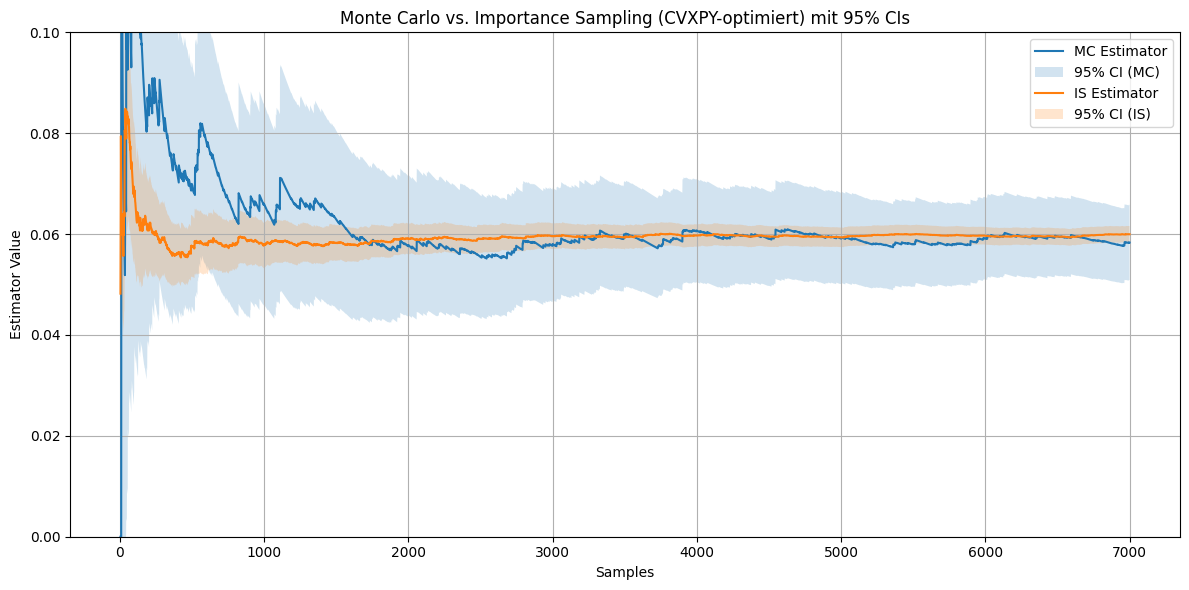

In [12]:
m_start = 5  # first index for estimation
m_axes = np.arange(m_start, M_eval + 1)

# === Optionen für Visualisierung (falls None -> automatisch) ===
y_axes_lower_visual = 0.0
y_axes_upper_visual = 0.1

f_val_mc_all = np.array([f(x_mc) for x_mc in X_eval])
f_val_is_all = np.array([f(x_is) for x_is in X_evalIS])
p_val_all = np.array([p_joint(x_is) for x_is in X_evalIS])
q_val_all = np.array([q_alpha(x_is) for x_is in X_evalIS])

weights = np.divide(p_val_all, q_val_all, out=np.zeros_like(p_val_all), where=q_val_all > 0)

MCE = np.zeros(M_eval + 1)
MCEIS = np.zeros(M_eval + 1)
Var_MCE = np.zeros(M_eval + 1)
Var_MCEIS = np.zeros(M_eval + 1)
low_MCE = np.zeros(M_eval + 1)
up_MCE = np.zeros(M_eval + 1)
low_IS = np.zeros(M_eval + 1)
up_IS = np.zeros(M_eval + 1)

for i in range(m_start, M_eval + 1):
    f_val_mc = f_val_mc_all[:i]
    f_val_is = f_val_is_all[:i]
    w_i = weights[:i]

    MCE[i] = np.mean(f_val_mc)
    Var_MCE[i] = np.var(f_val_mc, ddof=1)
    low_MCE[i] = MCE[i] - l * np.sqrt(Var_MCE[i] / i)
    up_MCE[i] = MCE[i] + l * np.sqrt(Var_MCE[i] / i)

    est_weighted = f_val_is * w_i
    MCEIS[i] = np.mean(est_weighted)
    Var_MCEIS[i] = np.var(est_weighted, ddof=1)
    low_IS[i] = MCEIS[i] - l * np.sqrt(Var_MCEIS[i] / i)
    up_IS[i] = MCEIS[i] + l * np.sqrt(Var_MCEIS[i] / i)

print("MC-Schätzer (letzter):", MCE[-1])
print("IS-Schätzer (letzter):", MCEIS[-1])

# === Plotting ===
plt.figure(figsize=(12, 6))
plt.plot(range(m_start, M_eval + 1), MCE[m_start:], label="MC Estimator")
plt.fill_between(range(m_start, M_eval + 1), low_MCE[m_start:], up_MCE[m_start:], alpha=0.2, label="95% CI (MC)")
plt.plot(range(m_start, M_eval + 1), MCEIS[m_start:], label="IS Estimator")
plt.fill_between(range(m_start, M_eval + 1), low_IS[m_start:], up_IS[m_start:], alpha=0.2, label="95% CI (IS)")
plt.xlabel("Samples")
plt.ylabel("Estimator Value")
plt.title("Monte Carlo vs. Importance Sampling (CVXPY-optimiert) mit 95% CIs")
plt.legend()
plt.grid(True)

# falls Grenzen gesetzt sind -> anwenden
if y_axes_lower_visual is not None and y_axes_upper_visual is not None:
    plt.ylim(y_axes_lower_visual, y_axes_upper_visual)

plt.tight_layout()
plt.show()
